In [3]:
from datasets import load_from_disk, load_dataset
from evaluate import load
import os 
from rich import print as pprint
import string
from collections import Counter
from scipy.stats import wasserstein_distance, ks_2samp, energy_distance
from scipy.spatial.distance import cosine
from scipy.spatial import distance
import numpy as np
from tqdm.auto import tqdm

import matplotlib.pyplot as plt 
from matplotlib import rcParams
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

/home/takis/anaconda3/envs/unlearning/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:


rcParams['font.family'] = 'serif'
rcParams['text.usetex'] = False
rcParams['font.size'] = 25

rcParams['axes.grid'] = False
rcParams['grid.linestyle'] = '--'
rcParams['grid.alpha'] = 0.9

rcParams['axes.facecolor'] = 'white'
# rcParams['axes.facecolor'] = '#f8f9fa'
# rcParams['axes.linewidth'] = 2
# rcParams['axes.axisbelow'] = True
rcParams['axes.labelsize'] = 25
rcParams['axes.titlesize'] = 30

rcParams['axes.spines.top'] = False
rcParams['axes.spines.right'] = False
rcParams['axes.spines.bottom'] = True
rcParams['axes.spines.left'] = True

rcParams['lines.linewidth'] = 4
rcParams['lines.markersize'] = 15

rcParams['legend.fontsize'] = 25
rcParams['xtick.labelsize'] = 20
rcParams['ytick.labelsize'] = 20
rcParams['figure.figsize'] = (4, 6)



In [7]:
datasets_path = '/data/takis/SynthGen/datasets'

benchmarks = ['BoolQ', 'GSM8K', 'AG']

sample_name = 'topK_50_topP_0.990_temp_0.800_reps_10.hf'
seed_name = 'topK_50_topP_0.990_temp_0.400_layer_16_denom_5.00_reps_10.hf'

mauve = load('mauve')

AG
8758 8025


100%|██████████| 8758/8758 [00:00<00:00, 59199.90it/s]

250583 14061


Cosine similarity: 0.9458842785619394
Jensen-Shannon divergence: 0.3590939610943206
KS statistic: 0.4469, p-value: 0.0000
Wasserstein distance: 72.5313
Energy distance: 6.6142


100%|██████████| 8025/8025 [00:00<00:00, 52939.56it/s]

242862 10065


Cosine similarity: 0.9120095317400098
Jensen-Shannon divergence: 0.4017574783452033
KS statistic: 0.4282, p-value: 0.0000
Wasserstein distance: 74.2466
Energy distance: 6.5323


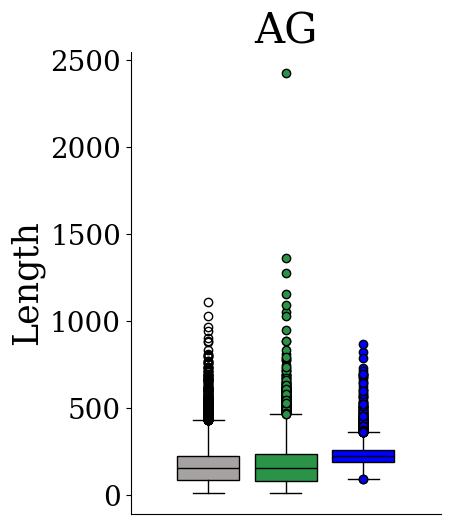

BoolQ
2412 2795


100%|██████████| 2412/2412 [00:00<00:00, 35630.45it/s]


178126 14594
Cosine similarity: 0.9922439222810453
Jensen-Shannon divergence: 0.31671863584888515
KS statistic: 0.2349, p-value: 0.0000
Wasserstein distance: 158.5670
Energy distance: 6.9241


100%|██████████| 2795/2795 [00:00<00:00, 31105.69it/s]


206453 11687
Cosine similarity: 0.9852587102106272
Jensen-Shannon divergence: 0.34572123060866056
KS statistic: 0.2740, p-value: 0.0000
Wasserstein distance: 164.5809
Energy distance: 7.6439


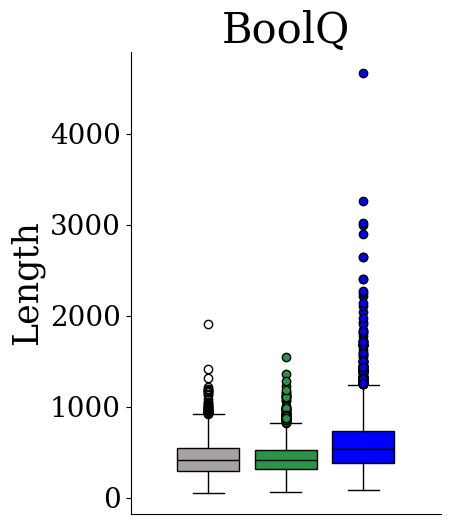

In [8]:
for b in ['AG', 'BoolQ']:

    print (b)



    if (b == 'BoolQ'):
        original_d = load_dataset("google/boolq", cache_dir='/data/takis/datasets/hf_hub')['validation']
    elif (b == 'GSM8K'):  
        original_d = load_dataset("openai/gsm8k", 'main', cache_dir='/data/takis/datasets/hf_hub')['test']
    elif (b == 'AG'):
        original_d = load_dataset("fancyzhx/ag_news", cache_dir='/data/takis/datasets/hf_hub')['test']


    original_prompts = []
    for d in original_d:
        prompt = ''
        for k in d.keys():
            prompt = prompt + str(d[k]).lower().translate(str.maketrans('', '', string.punctuation)) + ' '
        original_prompts.append(prompt)

    original_lengths = [len(p) for p in original_prompts]

    sample_d = load_from_disk(os.path.join(datasets_path, b + '_100', 'sample', sample_name))
    seed_d = load_from_disk(os.path.join(datasets_path, b + '_100', 'sample_seed', seed_name))

    print (len(sample_d), len(seed_d))


    sample_w = []
    sample_prompts = []
    for d in tqdm(sample_d, total=len(sample_d)):
        w = []
        prompt = ''
        for k in d.keys():
            prompt = prompt + str(d[k]).lower().translate(str.maketrans('', '', string.punctuation)) + ' '
            try:
                w += d[k].lower().translate(str.maketrans('', '', string.punctuation)).split(' ')
            except:
                pass
        sample_w.extend(w)
        sample_prompts.append(prompt)
    print (len(sample_w), len(set(sample_w)))
    
    sample_lengths = [len(p) for p in sample_prompts]

    original_counter = Counter((' '.join(original_prompts)).split(' '))
    sample_counter = Counter((' '.join(sample_prompts)).split(' '))

    all_keys = set(original_counter) | set(sample_counter)

    vec1 = np.array([original_counter.get(k, 0) for k in all_keys])
    vec2 = np.array([sample_counter.get(k, 0) for k in all_keys])

    # Normalize to probability distributions
    prob1 = vec1 / vec1.sum()
    prob2 = vec2 / vec2.sum()

    # Cosine similarity (1 = identical, 0 = orthogonal)
    cos_sim = 1 - cosine(prob1, prob2)

    # Jensen-Shannon divergence (lower = more similar)
    jsd = distance.jensenshannon(prob1, prob2)

    print(f"Cosine similarity: {cos_sim}")
    print(f"Jensen-Shannon divergence: {jsd}")
    
    # KS test
    ks_stat, ks_pval = ks_2samp(original_lengths, sample_lengths)

    # Wasserstein distance
    wdist = wasserstein_distance(original_lengths, sample_lengths)

    # Energy distance
    edist = energy_distance(original_lengths, sample_lengths)

    print(f"KS statistic: {ks_stat:.4f}, p-value: {ks_pval:.4f}")
    print(f"Wasserstein distance: {wdist:.4f}")
    print(f"Energy distance: {edist:.4f}")







    seed_w = []
    seed_prompts = []
    for d in tqdm(seed_d, total=len(seed_d)):
        w = []
        prompt = ''
        for k in d.keys():
            prompt = prompt + str(d[k]).lower().translate(str.maketrans('', '', string.punctuation)) + ' '
            try:
                w += d[k].lower().translate(str.maketrans('', '', string.punctuation)).split(' ')
            except:
                pass
        seed_w.extend(w)
        seed_prompts.append(prompt)
        
    seed_lengths = [len(p) for p in seed_prompts]

    print (len(seed_w), len(set(seed_w)))

    original_counter = Counter((' '.join(original_prompts)).split(' '))
    seed_counter = Counter((' '.join(seed_prompts)).split(' '))

    all_keys = set(original_counter) | set(seed_counter)

    vec1 = np.array([original_counter.get(k, 0) for k in all_keys])
    vec2 = np.array([seed_counter.get(k, 0) for k in all_keys])

    # Normalize to probability distributions
    prob1 = vec1 / vec1.sum()
    prob2 = vec2 / vec2.sum()

    # Cosine similarity (1 = identical, 0 = orthogonal)
    cos_sim = 1 - cosine(prob1, prob2)

    # Jensen-Shannon divergence (lower = more similar)
    jsd = distance.jensenshannon(prob1, prob2)

    print(f"Cosine similarity: {cos_sim}")
    print(f"Jensen-Shannon divergence: {jsd}")

    # KS test
    ks_stat, ks_pval = ks_2samp(original_lengths, seed_lengths)

    # Wasserstein distance
    wdist = wasserstein_distance(original_lengths, seed_lengths)

    # Energy distance
    edist = energy_distance(original_lengths, seed_lengths)

    print(f"KS statistic: {ks_stat:.4f}, p-value: {ks_pval:.4f}")
    print(f"Wasserstein distance: {wdist:.4f}")
    print(f"Energy distance: {edist:.4f}")


    box = plt.boxplot(sample_lengths, widths=[0.4], positions=[0], vert=True, medianprops={'color': 'black'}, patch_artist=True)
    for patch in box['boxes']:
        patch.set_facecolor('#a6a2a2')

    box = plt.boxplot(seed_lengths, widths=[0.4], positions=[0.5], vert=True, medianprops={'color': 'black'}, flierprops={'color': 'black','mfc': '#2b9348'}, patch_artist=True)
    for patch in box['boxes']:
        patch.set_facecolor('#2b9348')

    box = plt.boxplot(original_lengths, widths=[0.4], positions=[1], vert=True, medianprops={'color': 'black'}, flierprops={'color': 'black','mfc': 'blue'}, patch_artist=True)
    for patch in box['boxes']:
        patch.set_facecolor('blue')

    plt.xticks([], [])
    # plt.xlim((-0.4, 0.8))
    plt.title(b)
    plt.ylabel('Length')
    plt.show()



